# MTG FCI Level-1C — Cloud Investigation

This notebook loads and analyses data from the **Meteosat Third Generation (MTG) Flexible Combined Imager (FCI)**, a new-generation geostationary weather satellite operated by EUMETSAT at 0°E longitude.

## What is FCI?

FCI is the main imaging instrument on MTG. It scans the full Earth disk every 10 minutes across **16 spectral channels**, ranging from visible light (0.4 µm) to thermal infrared (13.3 µm). The Level-1C product contains calibrated radiances converted to:
- **Reflectance [%]** for visible/near-infrared channels (how much sunlight the scene reflects)
- **Brightness temperature [K]** for infrared channels (effective radiating temperature of the scene)

## Channels used in this notebook

| Channel | Wavelength | Measures | Resolution |
|---------|-----------|----------|-----------|
| **vis_06** | 0.6 µm | Reflected sunlight — clouds appear bright white | 1 km |
| **ir_105** | 10.5 µm | Emitted thermal radiation — brightness temperature ≈ cloud top temperature for opaque clouds | 2 km |

For the ir_105 channel, if a thick cloud fills the pixel, it radiates almost like a blackbody at its physical temperature. So the brightness temperature directly tells us how cold (and therefore how high) the cloud top is. Using the atmospheric lapse rate (~6.5 K/km), we can convert BT → cloud top height.

## Imports

- **satpy**: reads the FCI NetCDF files and handles calibration (raw counts → reflectance / brightness temperature)
- **cartopy**: geographic map projections and country/coastline overlays
- **pyproj**: coordinate transformations between projections (geostationary ↔ lon/lat)
- **dask**: satpy uses dask for lazy (deferred) loading — `scheduler='synchronous'` forces single-threaded execution to avoid HDF5 file-locking crashes

In [ ]:
from __future__ import annotations

import gc
import re
import warnings
warnings.filterwarnings('ignore')

import dask
dask.config.set(scheduler='synchronous')   # avoids HDF5 thread-safety segfaults

import csv
import glob
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import CRS, Transformer

from satpy import Scene
from satpy.writers import get_enhanced_image

In [11]:
# All 16 FCI spectral channels, ordered by wavelength.
# Each entry: (satpy dataset name, human-readable label, calibration type)
# Calibration type controls the colormap and units used when plotting:
#   'reflectance'           → grey colormap,   units = %
#   'brightness_temperature'→ grey_r colormap, units = K  (inverted: cold tops appear bright)
CHANNELS = [
    ('vis_04', '0.4 µm (VIS04)', 'reflectance'),
    ('vis_05', '0.5 µm (VIS05)', 'reflectance'),
    ('vis_06', '0.6 µm (VIS06)', 'reflectance'),
    ('vis_08', '0.8 µm (VIS08)', 'reflectance'),
    ('vis_09', '0.9 µm (VIS09)', 'reflectance'),
    ('nir_13', '1.3 µm (NIR13)', 'reflectance'),
    ('nir_16', '1.6 µm (NIR16)', 'reflectance'),
    ('nir_22', '2.2 µm (NIR22)', 'reflectance'),
    ('ir_38',  '3.8 µm (IR38)',  'brightness_temperature'),
    ('wv_63',  '6.3 µm (WV63)',  'brightness_temperature'),
    ('wv_73',  '7.3 µm (WV73)',  'brightness_temperature'),
    ('ir_87',  '8.7 µm (IR87)',  'brightness_temperature'),
    ('ir_97',  '9.7 µm (IR97)',  'brightness_temperature'),
    ('ir_105', '10.5 µm (IR105)', 'brightness_temperature'),
    ('ir_123', '12.3 µm (IR123)', 'brightness_temperature'),
    ('ir_133', '13.3 µm (IR133)', 'brightness_temperature'),
]

## Loading the data

### File structure
One FCI full-disk scan is split across **40 body files + 1 trail file**. Each body file covers a horizontal strip of the Earth disk (a few hundred rows), and the strips are ordered south-to-north — this reflects how the FCI scanning mirror physically sweeps the disk over ~10 minutes. We load all body files together as one scene (the trail file contains only metadata and is excluded).

The download script extracts the NC files from the ZIP archives automatically, so the data directory contains plain NC files ready to load.

In [12]:
DATA_DIR = '/scratch/l/L.Terzi/MTG-0degrees-FCI-Level1c/2026-08-05/'

# Collect all body NetCDF files (TRAIL files contain only metadata, no image data).
all_nc_files = [
    f for f in sorted(glob.glob(f'{DATA_DIR}/*.nc'))
    if 'TRAIL' not in f
]

# Group files by scan number encoded in the filename: _N__O_SSSS_KKKK.nc
# SSSS = scan number, KKKK = segment within that scan.
# This is more reliable than satpy's time-based group_files, which breaks when
# consecutive scans are back-to-back and timestamps bleed across scan boundaries.
_scan_map = defaultdict(list)
for f in all_nc_files:
    m = re.search(r'_N__O_(\d{4})_\d{4}\.nc$', f)
    if m:
        _scan_map[int(m.group(1))].append(f)

scan_groups = [_scan_map[k] for k in sorted(_scan_map)]
print(f'Found {len(scan_groups)} scan(s), {len(all_nc_files)} body files total.')

Found 85 scan(s), 3400 body files total.


In [ ]:
chosen_group = scan_groups[-1]

channel_names = [name for name, _, _ in CHANNELS]
scn = Scene(reader='fci_l1c_nc', filenames=chosen_group)
scn.load(channel_names)
print('Scene loaded (data not yet read from disk — lazy loading).')

In [14]:
# Crop the full-disk scene to Central Europe.
# Working with the full disk (~11000×11000 pixels per channel) would be very slow
# and memory-intensive. Cropping to a lon/lat bounding box keeps only the rows
# and columns that overlap with the region of interest.
EUROPE_BBOX = (-2.0, 45.0, 22.0, 57.0)   # lon_min, lat_min, lon_max, lat_max
eu_scn = scn.crop(ll_bbox=EUROPE_BBOX)
print('Scene cropped to Central Europe.')

Scene cropped to Central Europe.


In [15]:
# FCI data is stored in a geostationary projection (x/y in metres on the projection plane).
# To plot with cartopy we need the projection's CRS and the x/y coordinate vectors.
# VIS/NIR channels (1 km) and IR/WV channels (2 km) have different grids, so we
# cache the result by grid width to avoid recomputing it for every channel.
_area_cache: dict[int, tuple] = {}

def get_area_info(da):
    """Return (x, y, cartopy_crs) for the grid of a satpy DataArray.
    
    x and y are 1-D arrays of geostationary projection coordinates in metres.
    cartopy_crs is the matching Cartopy CRS, used as transform= in pcolormesh.
    """
    area = da.attrs['area']
    ncols = area.width          # unique key: 1 km and 2 km grids have different widths
    if ncols not in _area_cache:
        x, y = area.get_proj_vectors()
        _area_cache[ncols] = (x, y, area.to_cartopy_crs())
    return _area_cache[ncols]

## Overview: all 16 channels over Central Europe

The plot below shows all 16 FCI channels side by side. A few things to note:
- **VIS/NIR channels (rows 1–2):** grey colormap, values in reflectance %. Clouds are bright white. The 1.3 µm channel (NIR13) looks different because water vapour absorbs strongly there — high clouds appear normal, but the atmosphere below them is dark.
- **IR/WV channels (rows 3–4):** inverted grey colormap (`gray_r`), values in brightness temperature K. Cold cloud tops (= high clouds) appear bright white, just like in the visible channels — this makes it easy to compare the two.
- **Colour scale:** stretched per-channel to the 2nd–98th percentile to avoid a single bright/cold pixel dominating the scale.
- **Stride:** 1 km VIS/NIR channels are subsampled by 2 before plotting so their pixel density matches the 2 km IR channels on screen.

  [ 1/16] Rendering vis_04 ...
  [ 2/16] Rendering vis_05 ...
  [ 3/16] Rendering vis_06 ...
  [ 4/16] Rendering vis_08 ...
  [ 5/16] Rendering vis_09 ...
  [ 6/16] Rendering nir_13 ...
  [ 7/16] Rendering nir_16 ...
  [ 8/16] Rendering nir_22 ...
  [ 9/16] Rendering ir_38 ...
  [10/16] Rendering wv_63 ...
  [11/16] Rendering wv_73 ...
  [12/16] Rendering ir_87 ...
  [13/16] Rendering ir_97 ...
  [14/16] Rendering ir_105 ...
  [15/16] Rendering ir_123 ...
  [16/16] Rendering ir_133 ...

Saved: plots/fci_all_channels_europe.png


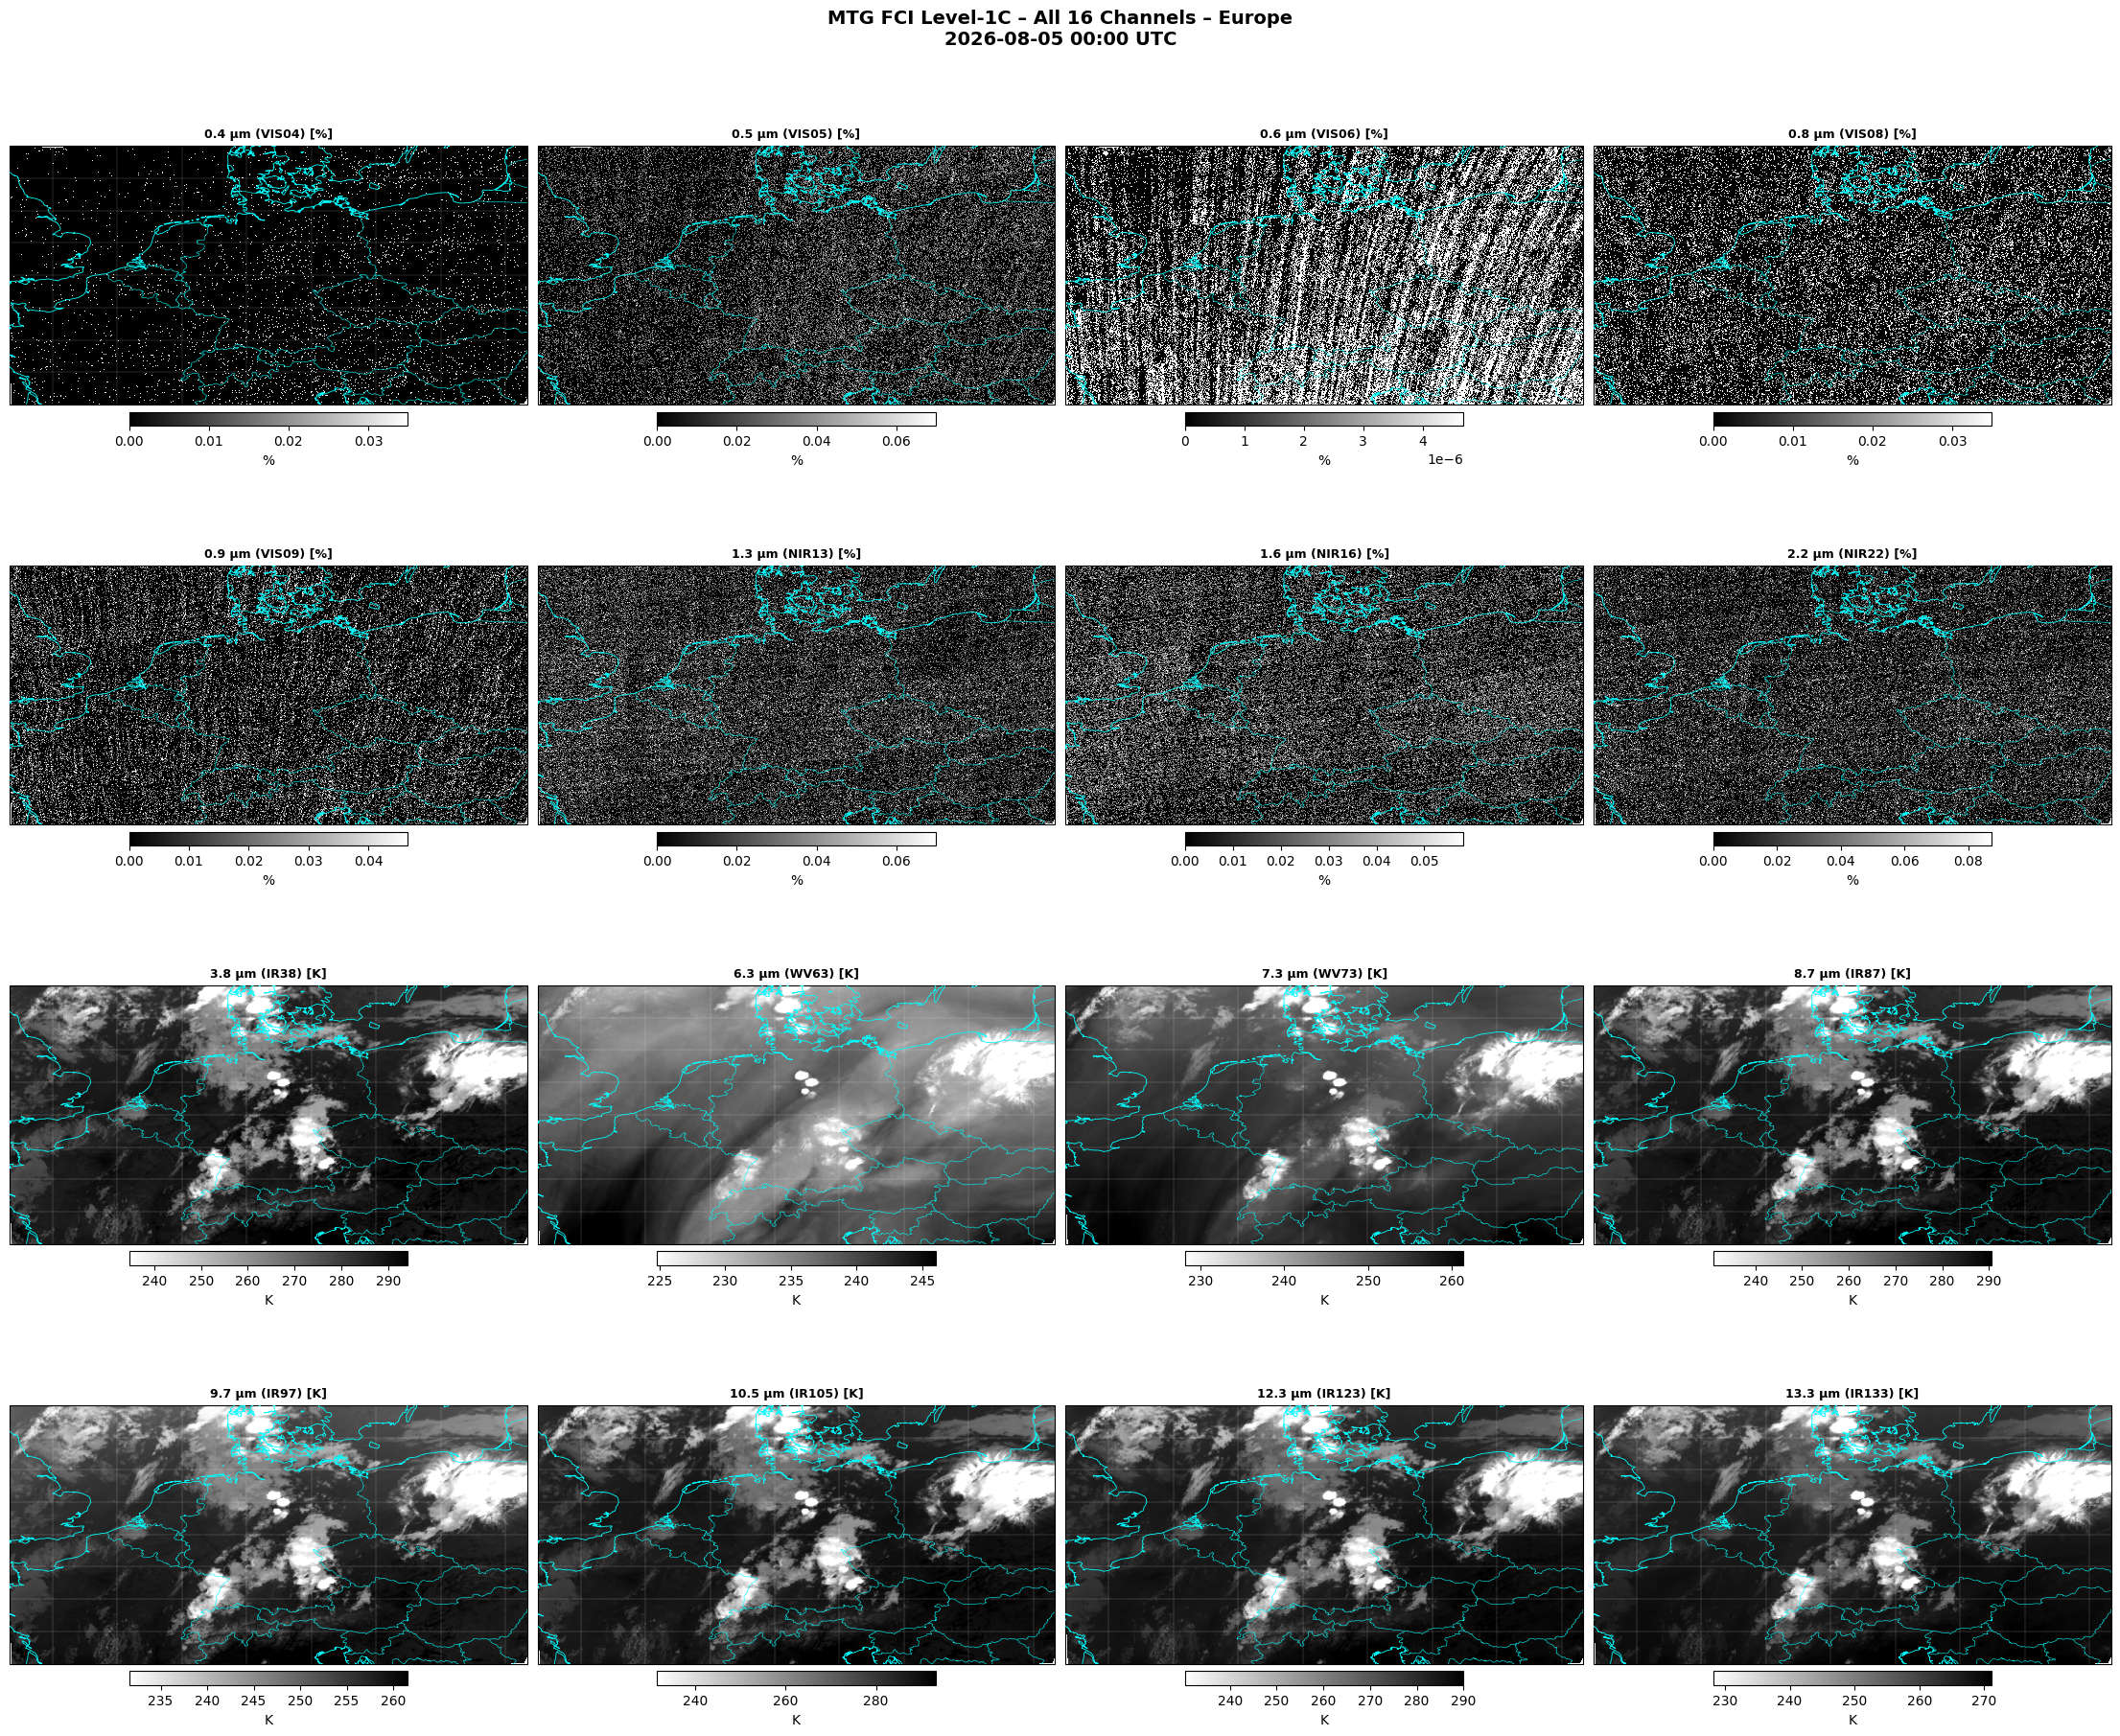

In [16]:
# now setup the figure and plot each channel:
ncols_fig, nrows_fig = 4, 4
fig, axes = plt.subplots(
    nrows_fig, ncols_fig,
    figsize=(22, 18),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

start_time_str = '' # this is only for the plotting title
for idx, (name, label, cal_type) in enumerate(CHANNELS):
    row, col = divmod(idx, ncols_fig)
    ax = axes[row, col]
    print(f'  [{idx+1:2d}/16] Rendering {name} ...', flush=True)

    da = eu_scn[name]
    arr = da.values.astype(np.float32)
    x, y, geos_crs = get_area_info(da)

    if not start_time_str:
        t = da.attrs.get('start_time', None)
        if t:
            start_time_str = t.strftime('%Y-%m-%d %H:%M UTC')

    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        ax.set_title(f'{label}\n(no valid data)', fontsize=9)
        continue

    if cal_type == 'reflectance':
        cmap = 'gray'
        vmin = 0.0
        vmax = float(np.percentile(valid, 99))
        units = '%'
    else:
        cmap = 'gray_r'  # cold cloud tops appear bright/white
        vmin = float(np.percentile(valid, 2))
        vmax = float(np.percentile(valid, 98))
        units = 'K'

    # Halve the 1 km channels so both resolutions plot at similar pixel density.
    stride = 2 if arr.shape[0] > 1500 else 1
    arr_plot = np.ma.masked_invalid(arr[::stride, ::stride])

    pcm = ax.pcolormesh(
        x[::stride], y[::stride], arr_plot,
        transform=geos_crs,
        cmap=cmap,
        shading='auto',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_extent([EUROPE_BBOX[0], EUROPE_BBOX[2], EUROPE_BBOX[1], EUROPE_BBOX[3]], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='cyan', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='cyan', zorder=3)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4, color='white', zorder=4)

    ax.set_title(f'{label} [{units}]', fontsize=9, fontweight='bold')
    plt.colorbar(
        pcm, ax=ax,
        orientation='horizontal', pad=0.02, fraction=0.04,
        label=units,
    )

title = 'MTG FCI Level-1C – All 16 Channels – Europe'
if start_time_str:
    title += f'\n{start_time_str}'
fig.suptitle(title, fontsize=14, fontweight='bold')

out_path = 'plots/fci_all_channels_europe.png'
fig.savefig(out_path, dpi=120)
#plt.close(fig)
print(f'\nSaved: {out_path}')


## Zooming in on the Zugspitze: Cloud Top Temperature

We now focus on two channels:
- **vis_06 (0.6 µm):** reflected sunlight — clouds appear **bright white**, clear sky is dark
- **ir_105 (10.5 µm):** emitted thermal radiation — we read the **brightness temperature (BT)** directly as cloud top temperature for opaque clouds

The idea: if a thick cloud sits over the Zugspitze, the ir_105 BT tells us how cold (= how high) the cloud top is. We can then use the standard atmospheric lapse rate (~6.5 K/km) to convert BT → cloud top height.

Both channels are already loaded in `eu_scn` because we loaded all 16 channels earlier.

In [17]:
# Zugspitze summit coordinates and the bounding box for the zoom plot.
# The bounding box covers roughly a 3° × 2° window centred on the Zugspitze,
# showing the surrounding Alps at a scale where individual 2 km IR pixels are visible.
ZUGSPITZE_LON = 10.985   # °E
ZUGSPITZE_LAT = 47.421   # °N

ZUGSPITZE_BBOX = (9.5, 46.4, 12.5, 48.4)   # lon_min, lat_min, lon_max, lat_max

### Extract vis_06 and ir_105 and find the Zugspitze pixel

We use the same approach as the all-channels plot: `get_area_info` gives us the native geostationary x/y coordinates, which we pass directly to `pcolormesh` with `transform=geos_crs`.

To find the nearest ir_105 pixel to the Zugspitze, we convert the Zugspitze lon/lat to geostationary x/y and look up the closest index in the 1-D coordinate arrays.

In [ ]:
da_vis = eu_scn['vis_06']
da_g08 = eu_scn['vis_08']
da_ir  = eu_scn['ir_105']

arr_vis = da_vis.values.astype(np.float32)
arr_g08 = da_g08.values.astype(np.float32)
arr_ir  = da_ir.values.astype(np.float32)

x_vis, y_vis, geos_crs_vis = get_area_info(da_vis)
x_g08, y_g08, geos_crs_g08 = get_area_info(da_g08)
x_ir,  y_ir,  geos_crs_ir  = get_area_info(da_ir)

time_str = da_ir.attrs.get('start_time').strftime('%Y-%m-%d %H:%M UTC')

### Side-by-side map: vis_06 and ir_105 zoomed in to the Zugspitze region

We plot both channels over the same tight bounding box. The red cross marks the Zugspitze pixel.

Note the **inverted grey-scale** for ir_105 (`gray_r`): cold cloud tops (high up in the atmosphere) appear **bright/white**, consistent with how bright clouds look in the visible channel — this makes it easy to compare the two panels.

In [ ]:
fig, (ax_vis, ax_g08, ax_ir) = plt.subplots(
    1, 3,
    figsize=(20, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

# vis_06 — reflectance, bright = cloud
pcm_vis = ax_vis.pcolormesh(
    x_vis, y_vis, np.ma.masked_invalid(arr_vis),
    transform=geos_crs_vis,
    cmap='gray', shading='auto',
    vmin=0.0, vmax=float(np.nanpercentile(arr_vis[np.isfinite(arr_vis)], 99)),
)
ax_vis.set_title(f'vis_06  (0.6 µm) – Reflectance\n{time_str}', fontsize=11)
plt.colorbar(pcm_vis, ax=ax_vis, orientation='horizontal', pad=0.04, fraction=0.046, label='Reflectance [%]')

# vis_08 — near-infrared green channel
pcm_g08 = ax_g08.pcolormesh(
    x_g08, y_g08, np.ma.masked_invalid(arr_g08),
    transform=geos_crs_g08,
    cmap='YlGn', shading='auto',
    vmin=0.0, vmax=float(np.nanpercentile(arr_g08[np.isfinite(arr_g08)], 99)),
)
ax_g08.set_title(f'vis_08  (0.8 µm) – Reflectance\n{time_str}', fontsize=11)
plt.colorbar(pcm_g08, ax=ax_g08, orientation='horizontal', pad=0.04, fraction=0.046, label='Reflectance [%]')

# ir_105 — brightness temperature
valid_ir = arr_ir[np.isfinite(arr_ir)]
pcm_ir = ax_ir.pcolormesh(
    x_ir, y_ir, np.ma.masked_invalid(arr_ir),
    transform=geos_crs_ir,
    cmap='gray_r', shading='auto',
    vmin=float(np.nanpercentile(valid_ir, 2)), vmax=float(np.nanpercentile(valid_ir, 98)),
)
ax_ir.set_title(f'ir_105 (10.5 µm) – Brightness Temperature\n{time_str}', fontsize=11)
plt.colorbar(pcm_ir, ax=ax_ir, orientation='horizontal', pad=0.04, fraction=0.046, label='Brightness temperature [K]')

# Zoom to Zugspitze region and add map features
for ax in (ax_vis, ax_g08, ax_ir):
    ax.set_extent([ZUGSPITZE_BBOX[0], ZUGSPITZE_BBOX[2], ZUGSPITZE_BBOX[1], ZUGSPITZE_BBOX[3]],
                  crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='cyan', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.6, edgecolor='cyan', zorder=3)
    ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor='#5588bb', alpha=0.6, zorder=3)
    ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5, color='gray', zorder=4)
    ax.scatter([ZUGSPITZE_LON], [ZUGSPITZE_LAT],
               c='red', s=150, marker='+', linewidths=2.5,
               transform=ccrs.PlateCarree(), zorder=6)

plt.savefig('plots/fci_vis06_vis08_ir105_zugspitze_zoom.png', dpi=150)
plt.show()

---
## Exercises

**Exercise 1:** Extract the cloud top temperature at the nearest Zugspitze pixel.

**Exercise 2:** Plot the time series of the cloud top temperature over all available scans.

**Exercise 3:** Is the brightness temperature actually the cloud top temperature? Interpret your results. *Hint: Do you always have clouds present?*

**Exercise 4:** Calculate a cloud cover from the neighbouring pixels around the Zugspitze. Use this to interpret whether your estimated cloud top temperature is actually a cloud top temperature or the temperature of the ground.

**Exercise 5:** Using the nearest pixel brightness temperature, estimate the cloud top height from the cloud top temperature.

---
## Solution

In [11]:
import pandas as pd

VIS06_CLOUD_THRESHOLD = 20.0  # % reflectance — above this is classified as cloudy
CLOUD_WINDOW_HALF = 2          # ±2 vis_06 pixels (1 km res) → 5×5 km neighbourhood
BT_WINDOW_HALF    = 1          # ±1 ir_105 pixel  (2 km res) → 3×3 pixels ≈ 6 km extent, closest match to 5 km

ZUG_CROP_BBOX = (10.0, 46.8, 12.0, 48.0)

# scan_groups is built in the data-loading cell above.
print(f'Using {len(scan_groups)} scan(s) for the time series.')
for i, group in enumerate(scan_groups[:5]):
    print(f'  Scan {i+1}: {len(group)} files')
if len(scan_groups) > 5:
    print(f'  ... ({len(scan_groups) - 5} more)')

Using 85 scan(s) for the time series.
  Scan 1: 40 files
  Scan 2: 40 files
  Scan 3: 40 files
  Scan 4: 40 files
  Scan 5: 40 files
  ... (80 more)


In [12]:
records = []

# Convert Zugspitze lon/lat to geostationary x/y once — same for every scan
geos_proj = CRS.from_proj4('+proj=geos +h=35786400 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m')
zug_x, zug_y = Transformer.from_crs(CRS.from_epsg(4326), geos_proj, always_xy=True).transform(
    ZUGSPITZE_LON, ZUGSPITZE_LAT
)

for i, group in enumerate(scan_groups):
    print(f'Processing scan {i+1}/{len(scan_groups)} ...', end=' ', flush=True)
    scn = None
    zug_scn = None
    try:
        scn = Scene(reader='fci_l1c_nc', filenames=group)
        scn.load(['vis_06', 'ir_105'])
        zug_scn = scn.crop(ll_bbox=ZUG_CROP_BBOX)

        da_ir  = zug_scn['ir_105']
        da_vis = zug_scn['vis_06']
        arr_ir  = da_ir.values.astype(np.float32)
        arr_vis = da_vis.values.astype(np.float32)

        # Nearest pixel in each channel's coordinate grid
        x_ir,  y_ir,  _ = get_area_info(da_ir)
        x_vis, y_vis, _ = get_area_info(da_vis)
        xi_ir  = int(np.argmin(np.abs(x_ir  - zug_x)));  yi_ir  = int(np.argmin(np.abs(y_ir  - zug_y)))
        xi_vis = int(np.argmin(np.abs(x_vis - zug_x)));  yi_vis = int(np.argmin(np.abs(y_vis - zug_y)))

        # Brightness temperature at the single nearest Zugspitze pixel
        bt_k = float(arr_ir[yi_ir, xi_ir])

        # Mean brightness temperature over the neighbourhood window
        h = BT_WINDOW_HALF
        r0, r1 = max(0, yi_ir - h), min(arr_ir.shape[0], yi_ir + h + 1)
        c0, c1 = max(0, xi_ir - h), min(arr_ir.shape[1], xi_ir + h + 1)
        ir_window = arr_ir[r0:r1, c0:c1].ravel()
        ir_window = ir_window[np.isfinite(ir_window)]
        bt_k_mean = float(np.mean(ir_window)) if ir_window.size > 0 else np.nan

        # Cloud fraction: fraction of vis_06 pixels in the 5×5 km neighbourhood above threshold
        h = CLOUD_WINDOW_HALF
        r0, r1 = max(0, yi_vis - h), min(arr_vis.shape[0], yi_vis + h + 1)
        c0, c1 = max(0, xi_vis - h), min(arr_vis.shape[1], xi_vis + h + 1)
        window = arr_vis[r0:r1, c0:c1].ravel()
        window = window[np.isfinite(window)]
        cloud_frac = float(np.mean(window > VIS06_CLOUD_THRESHOLD)) if window.size > 0 else np.nan

        scan_time = da_ir.attrs.get('start_time')
        records.append({
            'time': scan_time,
            'bt_k': bt_k, 'bt_c': bt_k - 273.15,
            'bt_k_mean': bt_k_mean, 'bt_c_mean': bt_k_mean - 273.15,
            'cloud_fraction': cloud_frac,
        })
        print(f'BT = {bt_k:.1f} K,  BT_mean = {bt_k_mean:.1f} K,  cloud fraction = {cloud_frac:.0%}')

    except Exception as e:
        print(f'FAILED — {e}')

    finally:
        del scn, zug_scn
        gc.collect()

print(f'\nDone. {len(records)} scan(s) processed.')

Processing scan 1/85 ... BT = 284.5 K,  BT_mean = 284.7 K,  cloud fraction = 0%
Processing scan 2/85 ... BT = 284.5 K,  BT_mean = 284.8 K,  cloud fraction = 0%
Processing scan 3/85 ... BT = 284.3 K,  BT_mean = 285.0 K,  cloud fraction = 0%
Processing scan 4/85 ... BT = 284.6 K,  BT_mean = 285.0 K,  cloud fraction = 0%
Processing scan 5/85 ... BT = 284.5 K,  BT_mean = 285.1 K,  cloud fraction = 0%
Processing scan 6/85 ... BT = 284.7 K,  BT_mean = 285.1 K,  cloud fraction = 0%
Processing scan 7/85 ... BT = 284.7 K,  BT_mean = 285.0 K,  cloud fraction = 0%
Processing scan 8/85 ... BT = 284.5 K,  BT_mean = 284.9 K,  cloud fraction = 0%
Processing scan 9/85 ... BT = 284.3 K,  BT_mean = 284.9 K,  cloud fraction = 0%
Processing scan 10/85 ... BT = 284.6 K,  BT_mean = 284.8 K,  cloud fraction = 0%
Processing scan 11/85 ... BT = 284.3 K,  BT_mean = 284.8 K,  cloud fraction = 0%
Processing scan 12/85 ... BT = 284.1 K,  BT_mean = 284.7 K,  cloud fraction = 0%
Processing scan 13/85 ... BT = 284.3 

In [13]:
df = pd.DataFrame(records).sort_values('time').reset_index(drop=True)
df.to_csv('plots/zugspitze_timeseries.csv', index=False)
print('Saved to plots/zugspitze_timeseries.csv')
df

Saved to plots/zugspitze_timeseries.csv


,time,bt_k,bt_c,bt_k_mean,bt_c_mean,cloud_fraction
0,2026-08-05 00:00:00,284.516602,11.366602,284.681305,11.531305,0.00
1,2026-08-05 00:10:00,284.479828,11.329828,284.828003,11.678003,0.00
2,2026-08-05 00:20:00,284.332703,11.182703,285.038391,11.888391,0.00
3,2026-08-05 00:30:00,284.626770,11.476770,284.994385,11.844385,0.00
4,2026-08-05 00:40:00,284.479828,11.329828,285.107727,11.957727,0.00
...,...,...,...,...,...,...
80,2026-08-05 13:20:00,290.681335,17.531335,289.890533,16.740533,0.72
81,2026-08-05 13:30:00,290.577545,17.427545,288.112823,14.962823,0.68
82,2026-08-05 13:40:00,289.533722,16.383722,287.267822,14.117822,0.68
83,2026-08-05 13:50:00,289.218567,16.068567,287.628571,14.478571,0.64


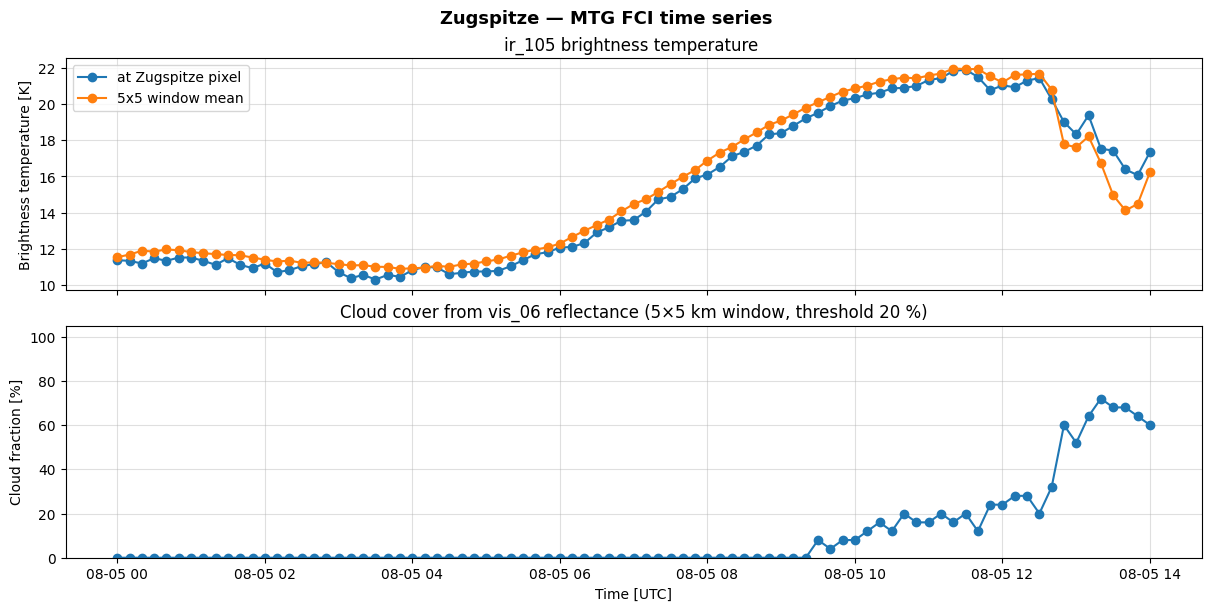

In [14]:
fig, (ax_bt, ax_cf) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)

ax_bt.plot(df['time'], df['bt_c'], marker='o', color='C0', linewidth=1.5, label='at Zugspitze pixel')
ax_bt.plot(df['time'], df['bt_c_mean'], marker='o', color='C1', linewidth=1.5, label='5x5 window mean')
ax_bt.set_ylabel('Brightness temperature [K]')
ax_bt.set_title('ir_105 brightness temperature ')
ax_bt.grid(alpha=0.4)
ax_bt.legend()

ax_cf.plot(df['time'], df['cloud_fraction'] * 100, marker='o', color='C0', linewidth=1.5)
ax_cf.set_ylabel('Cloud fraction [%]')
ax_cf.set_ylim(0, 105)
ax_cf.set_xlabel('Time [UTC]')
ax_cf.set_title(f'Cloud cover from vis_06 reflectance (5×5 km window, threshold {VIS06_CLOUD_THRESHOLD:.0f} %)')
ax_cf.grid(alpha=0.4)

fig.suptitle('Zugspitze — MTG FCI time series', fontsize=13, fontweight='bold')
plt.savefig('plots/zugspitze_timeseries.png', dpi=150)
plt.show()